# Livrable 1 
Groupe : 
* Isrâ BOUDEMAGH
* Théophile NOEL
* Bruno RIECKENBERG
* Corentin ROMANO

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
import pathlib
import shutil

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

print(tf.__version__)
print("Compilé avec CUDA :", tf.test.is_built_with_cuda())
print("GPU détectés :", tf.config.list_physical_devices('GPU'))


I0000 00:00:1790771866.507500   13200 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790771867.484754   13200 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790771869.966230   13200 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0
Compilé avec CUDA : True
GPU détectés : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1790771872.148867   13200 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
dataset_path = pathlib.Path("./Livrable1.1/dataset")
print([p.name for p in dataset_path.iterdir()])

['Others', 'Painting', 'Photo']


In [3]:
from PIL import Image
import shutil

def nettoyer_dataset(root, dossier_rejets):
    root, dossier_rejets = pathlib.Path(root), pathlib.Path(dossier_rejets)
    reparees, rejetees = [], []
    for p in sorted(root.rglob("*")):
        if not p.is_file():
            continue
        try:
            tf.io.decode_image(tf.io.read_file(str(p)), channels=3, expand_animations=False)
        except tf.errors.InvalidArgumentError:
            try:
                with Image.open(p) as im:
                    im = im.convert("RGB")
                im.save(p, "JPEG", quality=95)   # ré-encodage en vrai JPEG
                reparees.append(p)
            except Exception:
                cible = dossier_rejets / p.relative_to(root)
                cible.parent.mkdir(parents=True, exist_ok=True)
                shutil.move(str(p), str(cible))  # image illisible : on la sort du dataset
                rejetees.append(p)
    print(f"{len(reparees)} réparée(s), {len(rejetees)} rejetée(s)")
    return reparees, rejetees

nettoyer_dataset(dataset_path, "./Livrable1_rejets")


W0000 00:00:1790771872.818272   13200 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790771873.205678   13200 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1790772149.026488   13200 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


0 réparée(s), 0 rejetée(s)


([], [])

In [4]:
image_h = 200
image_w = 200
batch_s = 128

In [5]:
# Le train_set
train_set = tf.keras.preprocessing.image_dataset_from_directory(
  dataset_path,
  validation_split=  0.2,
  subset =  'training',
  seed=42,
  image_size = (image_h, image_w),
  batch_size = batch_s
)
# Le test_set
test_set = tf.keras.preprocessing.image_dataset_from_directory(
  dataset_path,
  validation_split= 0.2,
  subset = 'validation',
  seed= 42,
  image_size = (image_h, image_w),
  batch_size = batch_s
)

Found 41399 files belonging to 3 classes.
Using 33120 files for training.
Found 41399 files belonging to 3 classes.
Using 8279 files for validation.


In [6]:
class_names = train_set.class_names
print(class_names)

['Others', 'Painting', 'Photo']


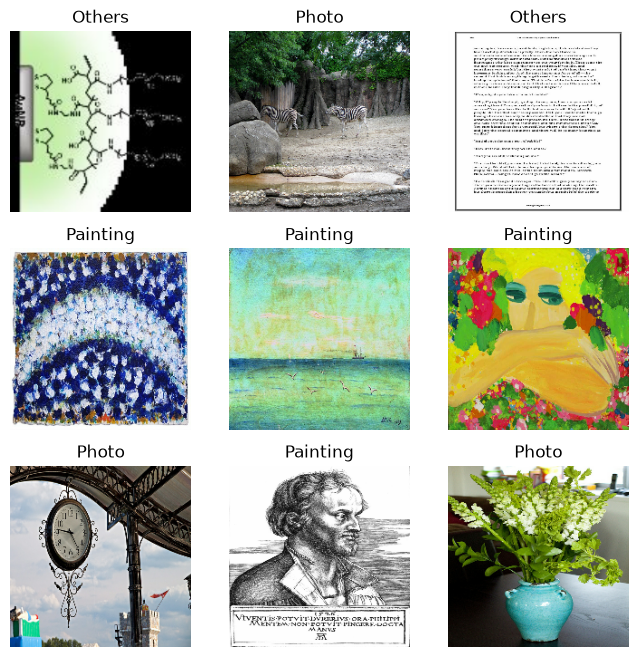

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train_set.take(1):
    for i in range(9):
        ax = plt.subplot(3,3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [8]:
print(type(train_set))
images, labels =  next(iter(train_set))
print(images.shape)
print(labels.shape)

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
(128, 200, 200, 3)
(128,)


In [9]:
# AUTOTUNE = tf.data.experimental.AUTOTUNE

# train_set = train_set.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
# test_set = test_set.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(image_h, image_w, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

/home/theophile/envs/tf-gpu/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    20,480,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,578,467 (78.50 MB)

 Trainable params: 20,578,467 (78.50 MB)

 Non-trainable params: 0 (0.00 B)

...

259/259 ━━━━━━━━━━━━━━━━━━━━ 50s 191ms/step - accuracy: 0.9531 - loss: 0.1297 - val_accuracy: 0.9209 - val_loss: 0.2237 - learning_rate: 1.0000e-05
Epoch 35/150
126/259 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.9527 - loss: 0.1286

W0000 00:00:1790774076.523470   21747 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9528 - loss: 0.1274

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


259/259 ━━━━━━━━━━━━━━━━━━━━ 50s 191ms/step - accuracy: 0.9528 - loss: 0.1274 - val_accuracy: 0.9194 - val_loss: 0.2289 - learning_rate: 1.0000e-05
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 20.


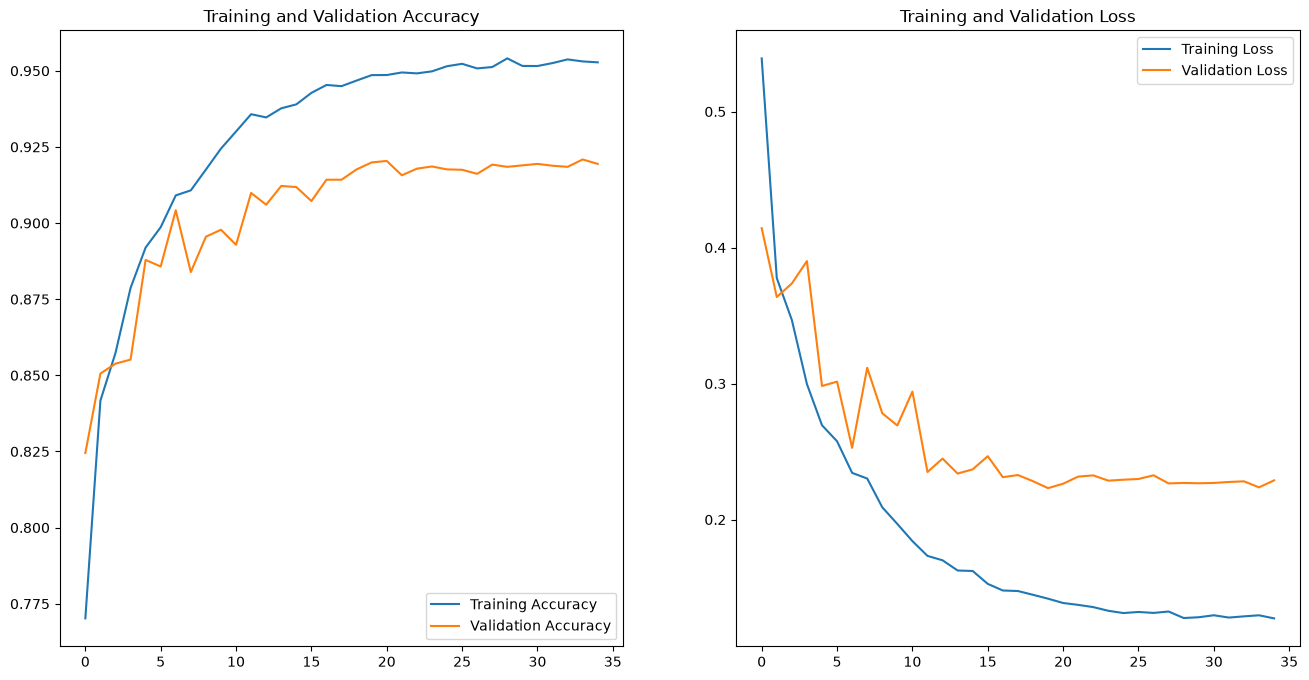

In [11]:
epochs=150
learning_rate = 1e-3
# Le modèle
complete_model =  Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(image_h, image_w, 3)),
    layers.Conv2D(16, (3, 3), padding='same', activation='leaky_relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3, 3), padding='same', activation='leaky_relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), padding='same', activation='leaky_relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), padding='same', activation='leaky_relu'),
    layers.Flatten(),
    layers.Dense(256, activation='leaky_relu'),
    layers.Dropout(0.2),  # Couche de dropout pour régularisation
    layers.Dense(3, activation='softmax')  # 3 classes de sortie
])
# Compilation du modèle
complete_model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                       metrics=['accuracy'])
#Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=epochs//10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.75,
    patience=epochs//100,
    min_lr=0.00001,
    verbose=1
)
# Résumé du modèle
complete_model.summary()
# Entrainement du modèle
complete_history = complete_model.fit(train_set,
                                      epochs=epochs,
                                      validation_data=(test_set),
                                      callbacks=[reduce_lr, early_stopping])
acc = complete_history.history['accuracy']
val_acc = complete_history.history['val_accuracy']

loss = complete_history.history['loss']
val_loss = complete_history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


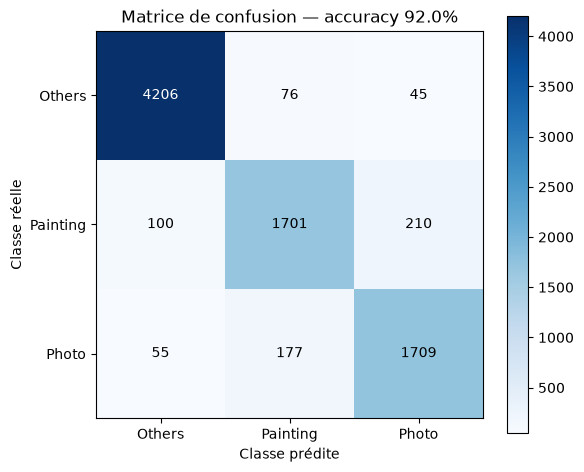

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


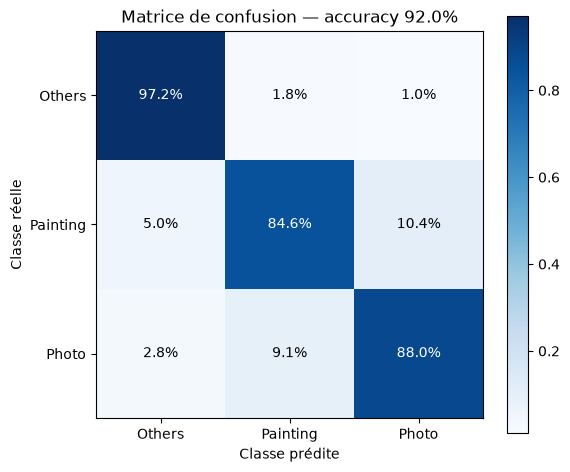

In [15]:
def afficher_matrice_confusion(model, dataset, class_names, normaliser=False):
    y_true, y_pred = [], []
    # On prédit batch par batch dans la MÊME boucle que les labels (voir remarque plus bas)
    for images, labels in dataset:
        logits = model.predict_on_batch(images)
        y_true.append(labels.numpy())
        y_pred.append(np.argmax(logits, axis=1))
    y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()
    if normaliser:
        cm = cm / cm.sum(axis=1, keepdims=True)   # proportions par classe réelle

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)), labels=class_names)
    ax.set_yticks(range(len(class_names)), labels=class_names)
    ax.set_xlabel("Classe prédite")
    ax.set_ylabel("Classe réelle")
    ax.set_title(f"Matrice de confusion — accuracy {np.mean(y_true == y_pred):.1%}")

    # Valeur écrite dans chaque case (texte blanc sur les cases foncées)
    seuil = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            texte = f"{cm[i, j]:.1%}" if normaliser else f"{cm[i, j]:d}"
            ax.text(j, i, texte, ha="center", va="center",
                    color="white" if cm[i, j] > seuil else "black")

    plt.tight_layout()
    plt.show()
    return cm

cm = afficher_matrice_confusion(complete_model, test_set, class_names)
cm_norm = afficher_matrice_confusion(complete_model, test_set, class_names, normaliser=True)


In [13]:
model_path = pathlib.Path("./Livrable1.1/models")
model_path.mkdir(exist_ok=True, parents=True)

complete_model.save(model_path / "lucky_model1.1.keras")
print(f"Modèle sauvegardé dans : {model_path.resolve()}")

Modèle sauvegardé dans : /mnt/c/CESI/FISE A5 26-27/Option 1/Projet/Livrable1.1/models


In [14]:
model_file_path = model_path / "lucky_model2.keras"
complete_model = keras.models.load_model(model_file_path)

complete_model.summary()
complete_model.evaluate(test_set)

ValueError: File not found: filepath=Livrable1.1/models/lucky_model2.keras. Please ensure the file is an accessible `.keras` zip file.

Jauconde.jpg                 → Painting  | Others   0.0%  Painting 100.0%  Photo   0.0%
Terre.jpg                    → Others    | Others  58.3%  Painting   9.0%  Photo  32.7%
etrange.jpg                  → Photo     | Others   0.0%  Painting   4.4%  Photo  95.6%
homme devant fenetre.jpg     → Photo     | Others   0.3%  Painting   7.2%  Photo  92.4%
nuit sous les étoiles.jpg    → Painting  | Others   0.2%  Painting  99.7%  Photo   0.0%
peinture wiki.jpg            → Painting  | Others   0.1%  Painting  82.5%  Photo  17.4%
photo1.jpg                   → Photo     | Others   0.0%  Painting  34.6%  Photo  65.4%
photo2.jpg                   → Photo     | Others   1.2%  Painting  27.2%  Photo  71.6%
photo3.jpg                   → Photo     | Others   3.9%  Painting   8.1%  Photo  88.0%
photo4.jpg                   → Others    | Others  77.9%  Painting  21.9%  Photo   0.2%
tropius.jpg                  → Others    | Others  67.9%  Painting  27.6%  Photo   4.5%
voie_lactée.jpg              → P

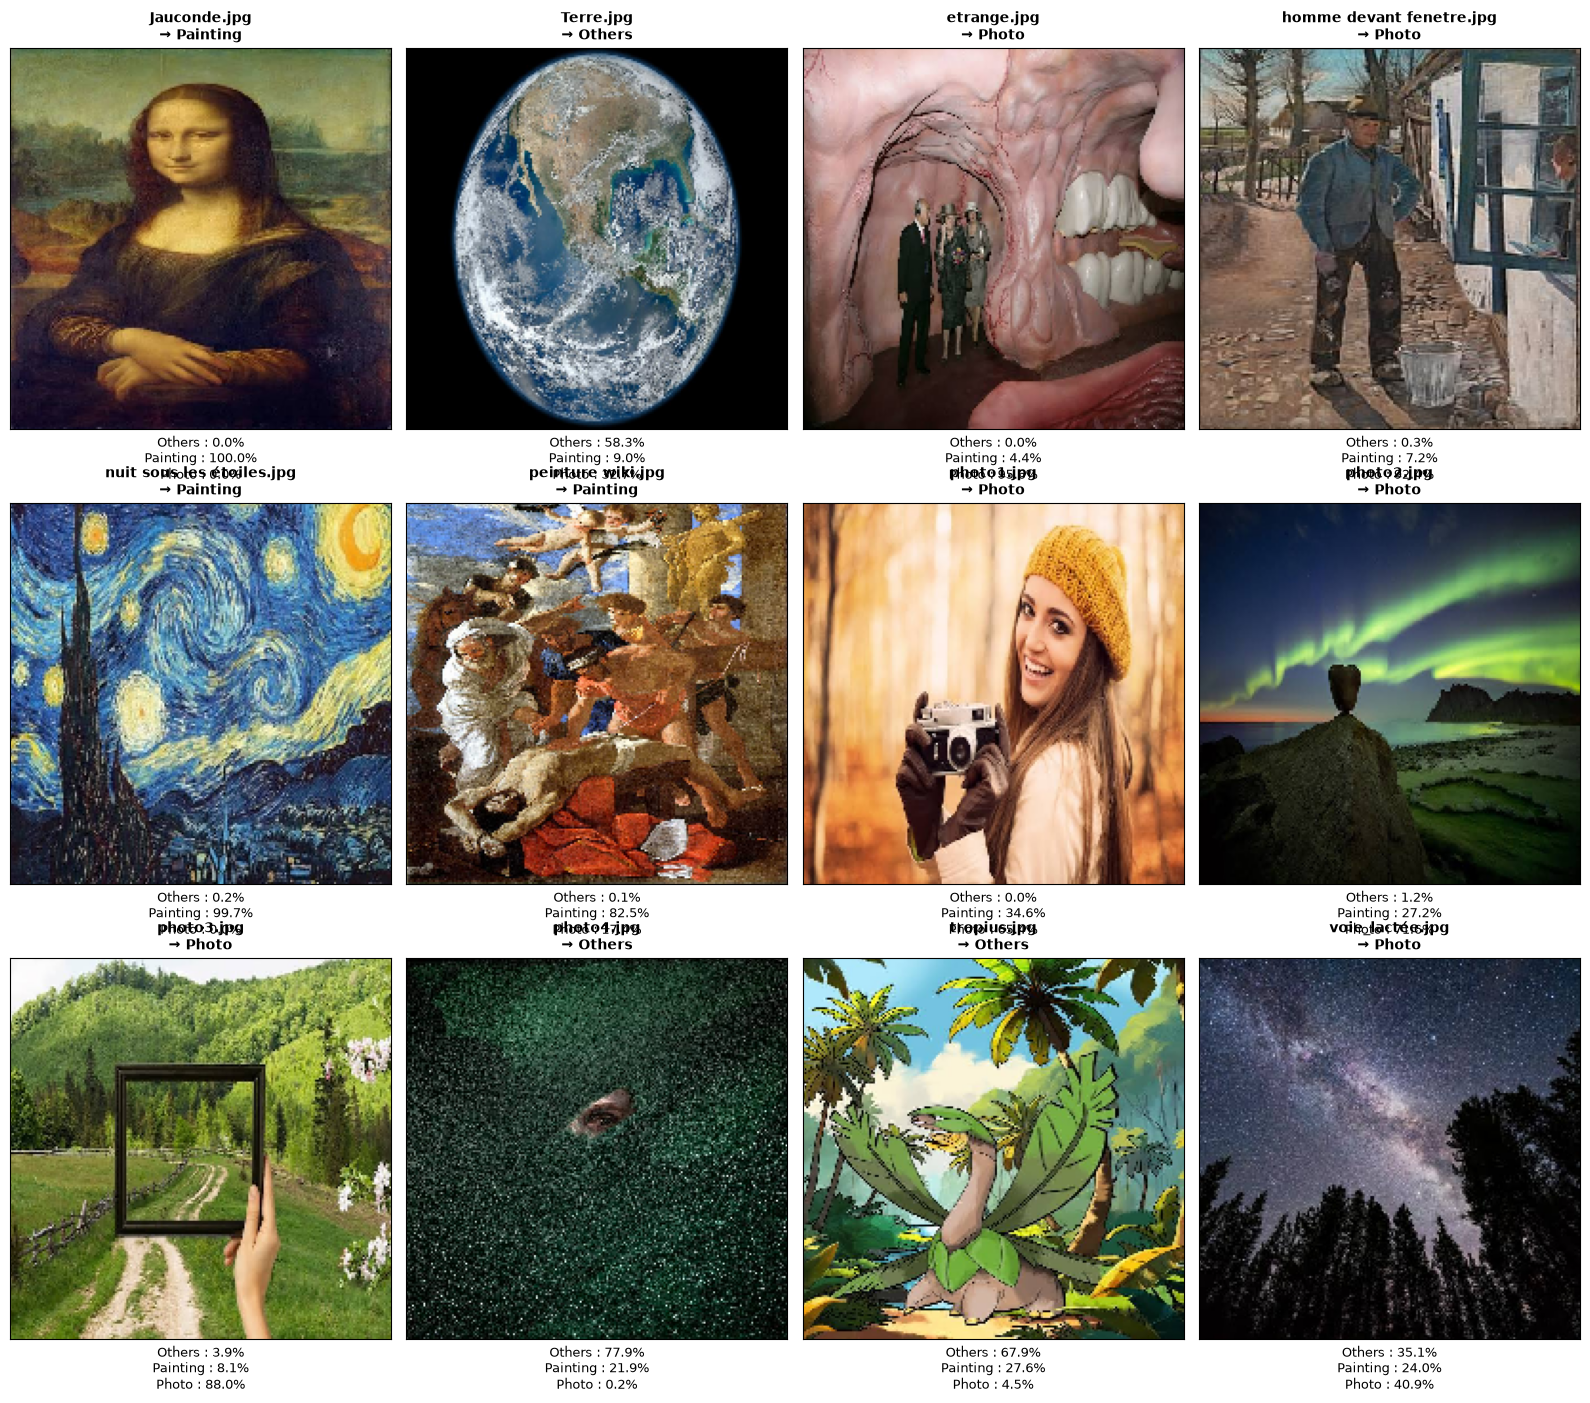

In [16]:
test_photos_dir = pathlib.Path("./Test_photos")
extensions_images = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
nb_colonnes = 4

# Le modèle doit avoir autant de sorties que de classes (3 : Others, Painting, Photo)
nb_sorties = complete_model.output_shape[-1]
if nb_sorties != len(class_names):
    raise ValueError(
        f"Le modèle a {nb_sorties} sorties mais il y a {len(class_names)} classes {class_names}. "
        "Vérifie que complete_model est bien le modèle entraîné sur ce dataset."
    )

# Si la dernière couche a déjà un softmax, ses sorties sont des probabilités : on ne le réapplique pas
sortie_softmax = getattr(complete_model.layers[-1].activation, "__name__", "") == "softmax"

if not test_photos_dir.is_dir():
    raise FileNotFoundError(f"Dossier introuvable : {test_photos_dir.resolve()}")

image_paths = sorted(
    p for p in test_photos_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in extensions_images
)

if not image_paths:
    print(f"Aucune image trouvée dans {test_photos_dir.resolve()}")
else:
    images = [keras.utils.load_img(p, target_size=(image_h, image_w), color_mode="rgb") for p in image_paths]
    batch = np.stack([keras.utils.img_to_array(img) for img in images])

    # Une seule prédiction pour toutes les images (plus rapide et moins de mémoire qu'une par image)
    sorties = complete_model.predict(batch, verbose=0)
    probabilities = sorties if sortie_softmax else tf.nn.softmax(sorties, axis=1).numpy()

    nb_lignes = int(np.ceil(len(images) / nb_colonnes))
    fig = plt.figure(figsize=(4 * nb_colonnes, 4.6 * nb_lignes))
    for i, (image_path, image, probas) in enumerate(zip(image_paths, images, probabilities)):
        predicted_index = int(np.argmax(probas))
        detail = "\n".join(f"{name} : {p:.1%}" for name, p in zip(class_names, probas))

        ax = fig.add_subplot(nb_lignes, nb_colonnes, i + 1)
        ax.imshow(image)
        ax.set_title(f"{image_path.name}\n→ {class_names[predicted_index]}", fontsize=10, fontweight="bold")
        ax.set_xlabel(detail, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

        print(f"{image_path.name:<28} → {class_names[predicted_index]:<9} | "
              + "  ".join(f"{name} {p:6.1%}" for name, p in zip(class_names, probas)))

    plt.tight_layout()
    plt.show()
    plt.close(fig)